# Практическое занятие №5: Визуализация данных с Matplotlib и Seaborn

## Цель занятия

Освоить основные приёмы визуализации данных с использованием библиотек
Matplotlib и Seaborn. Научиться выбирать подходящий тип графика для разных
задач анализа, строить и настраивать графики, интерпретировать полученные
результаты.

Задачи
1. Изучить возможности библиотек Matplotlib и Seaborn.
2. Научиться строить основные типы графиков: линейные, гистограммы,
ящики с усами, scatter plot, тепловые карты, pairplot, bar plot, violin plot.
3. Освоить настройку внешнего вида графиков: размер, подписи, легенда,
цветовые палитры.
4. Применить визуализацию для разведочного анализа данных (EDA) на
реальных датасетах.
5. Создать комплексный отчёт с графиками по выбранному датасету.

## Основные команды и настройки

```
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стиля seaborn
sns.set_style("whitegrid")
sns.set_palette("deep")

# Создание фигуры и осей
fig, ax = plt.subplots(figsize=(10, 6))

# Построение графика (пример)
sns.histplot(data=df, x='age', bins=30, ax=ax)
ax.set_title('Распределение возраста')ax.set_xlabel('Возраст')
ax.set_ylabel('Частота')

# Показать график
plt.tight_layout()
plt.show()
```

### Пример 1: Анализ выживаемости на Титанике (Seaborn)

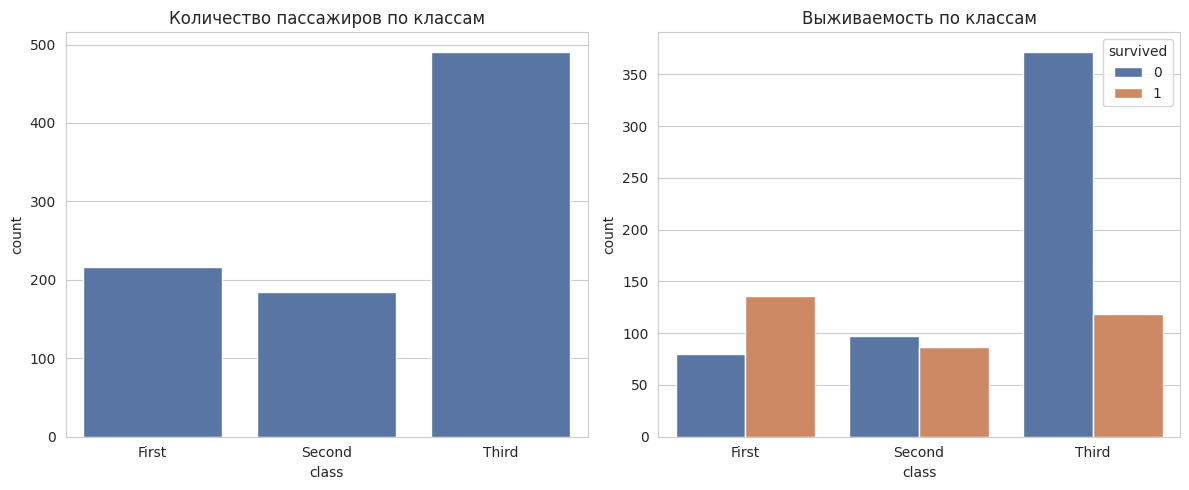

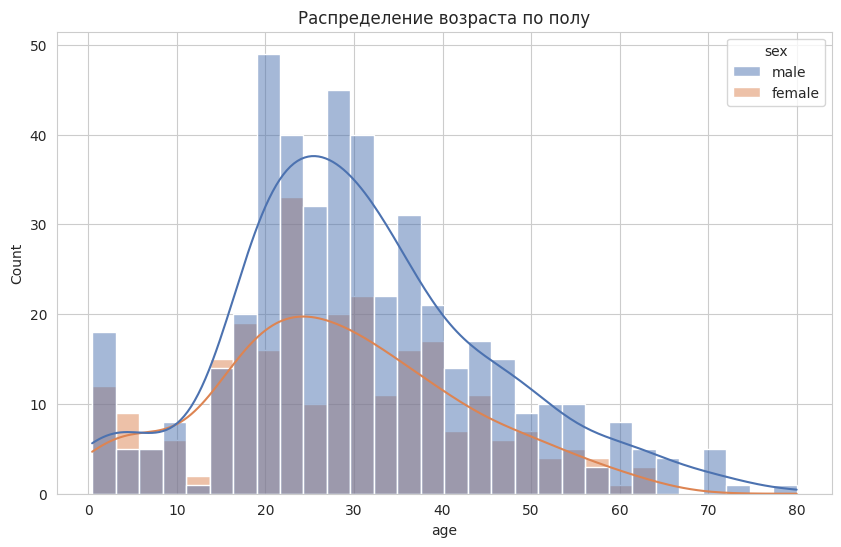

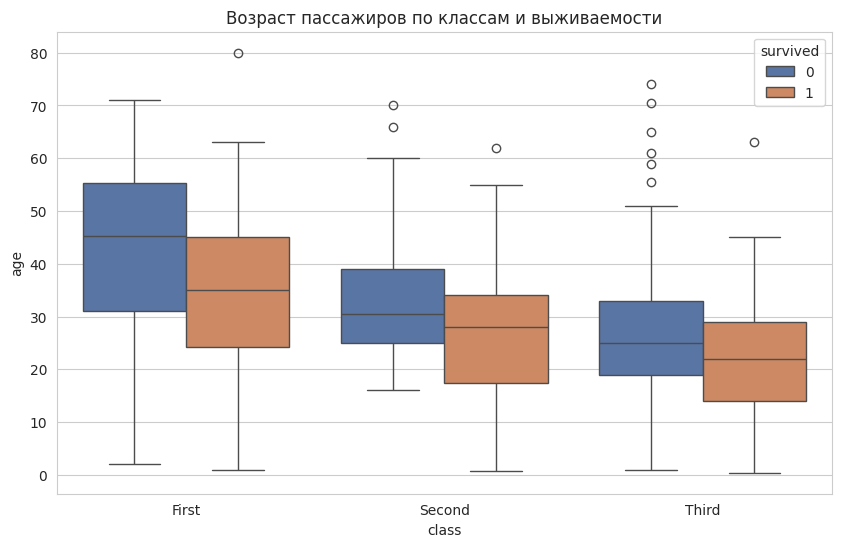

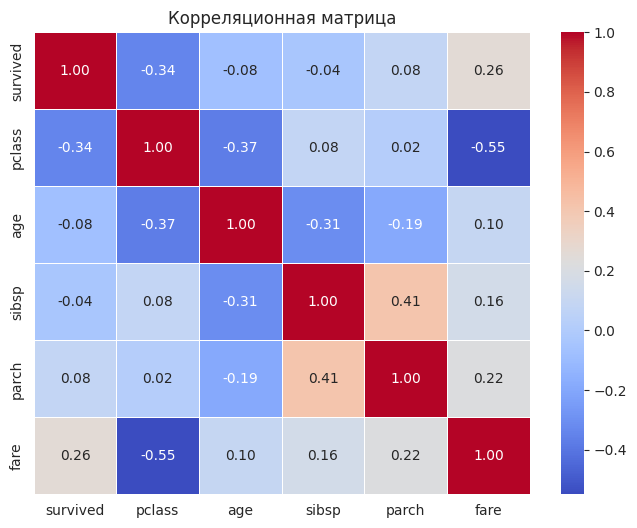

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = sns.load_dataset('titanic')
# 1. Счётный график по классу и выживаемости
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='class', ax=axes[0])
axes[0].set_title('Количество пассажиров по классам')
sns.countplot(data=df, x='class', hue='survived', ax=axes[1])
axes[1].set_title('Выживаемость по классам')
plt.tight_layout()
plt.show()
# 2. Распределение возраста с разбивкой по полу
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='sex', kde=True, bins=30)
plt.title('Распределение возраста по полу')
plt.show()
# 3. Ящик с усами для возраста по классам
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='class', y='age', hue='survived')
plt.title('Возраст пассажиров по классам и выживаемости')
plt.show()
# 4. Тепловая карта корреляций числовых признаков
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

### Пример 2: Анализ чаевых в ресторане (Scatter plot, violin plot)

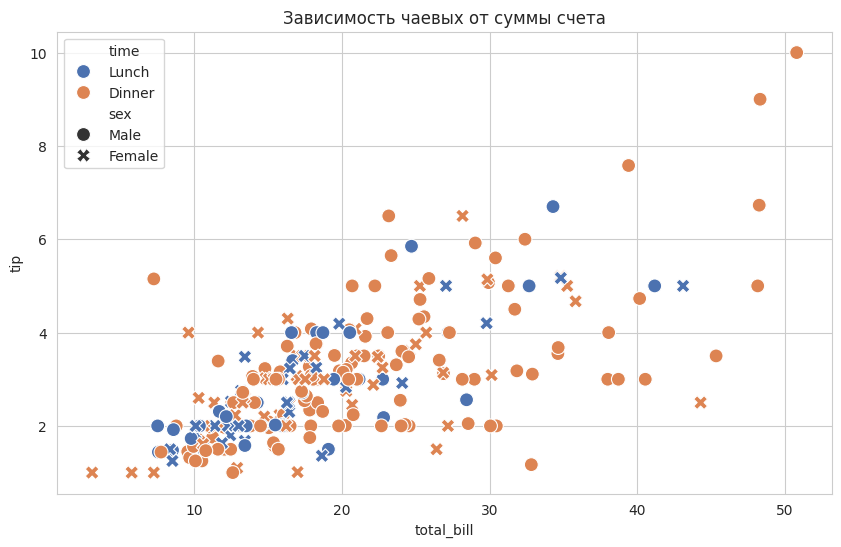

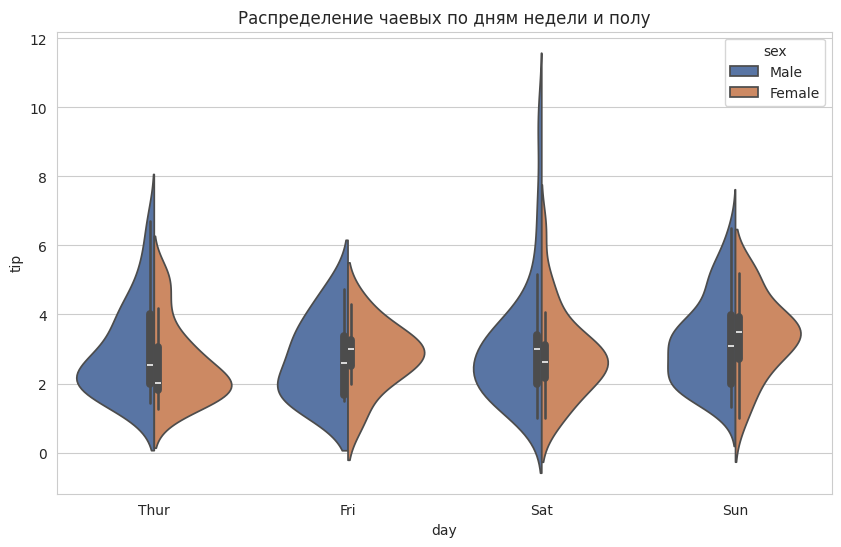

In [6]:
df = sns.load_dataset('tips')
# 1. Зависимость чаевых от суммы счёта с разделением по времени дня
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time',
style='sex', s=100)
plt.title('Зависимость чаевых от суммы счета')
plt.show()
# 2. Скрипичный график для чаевых по дням недели
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='day', y='tip', hue='sex', split=True)
plt.title('Распределение чаевых по дням недели и полу')
plt.show()

### Пример 3: Временной ряд (линейный график)

In [9]:
# Загрузка данных о пассажирах авиалиний
df = sns.load_dataset('flights')

# Преобразование месяца в число
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5,
'Jun':6,
'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11,
'Dec':12}
df['month_num'] = df['month'].map(month_map)
df['date'] = pd.to_datetime(df[['year','month_num']].assign(day=1))

# Линейный график
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y='passengers')
plt.title('Динамика пассажиропотока')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ValueError: to assemble mappings requires at least that [year, month, day] be specified: [month] is missing